# Notebook 04: Evaluation & Visualisation
**Thesis:** Autonomous Threat Hunting: ML-Based MITRE ATT&CK Technique Detection

**What this notebook does:**
- Loads results from Notebook 03
- Generates thesis-ready figures:
  - Model comparison bar chart
  - Confusion matrices for all 3 models
  - Feature importance chart
- Saves all figures as PNG files to results/figures/

**Input:** `results/model_comparison.csv`, `results/predictions.csv`, `results/feature_importance.csv`  
**Output:** `results/figures/` (PNG charts for thesis)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Create output folder for figures
os.makedirs('../results/figures', exist_ok=True)

# Style settings for professional thesis figures
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('=== NOTEBOOK 04: EVALUATION & VISUALISATION ===')
print('Libraries imported successfully')

=== NOTEBOOK 04: EVALUATION & VISUALISATION ===
Libraries imported successfully


In [9]:
# Load results from Notebook 03
results     = pd.read_csv('../results/model_comparison.csv')
predictions = pd.read_csv('../results/predictions.csv')
feat_imp    = pd.read_csv('../results/feature_importance.csv')
label_map   = pd.read_csv('../data/processed/label_map.csv')

# Build class names from actual predictions
actual_classes = sorted(predictions['y_true'].unique())
class_names    = [label_map.loc[label_map['encoded'] == i, 'technique'].values[0] for i in actual_classes]
# Shorten names for chart readability
short_names = [name.replace('T1021_RemoteServices', 'T1021\nRemote Services')
                   .replace('T1110_BruteForce', 'T1110\nBrute Force') for name in class_names]

print('Results loaded:')
print(results[['Model','Accuracy','F1 Score']].to_string(index=False))
print()
print(f'Classes: {class_names}')

Results loaded:
               Model  Accuracy  F1 Score
       Random Forest  0.978175  0.975199
             XGBoost  0.978175  0.975199
Neural Network (MLP)  0.962462  0.954672

Classes: ['T1021', 'T1110']


Generating Figure 1: Model Comparison Bar Chart...


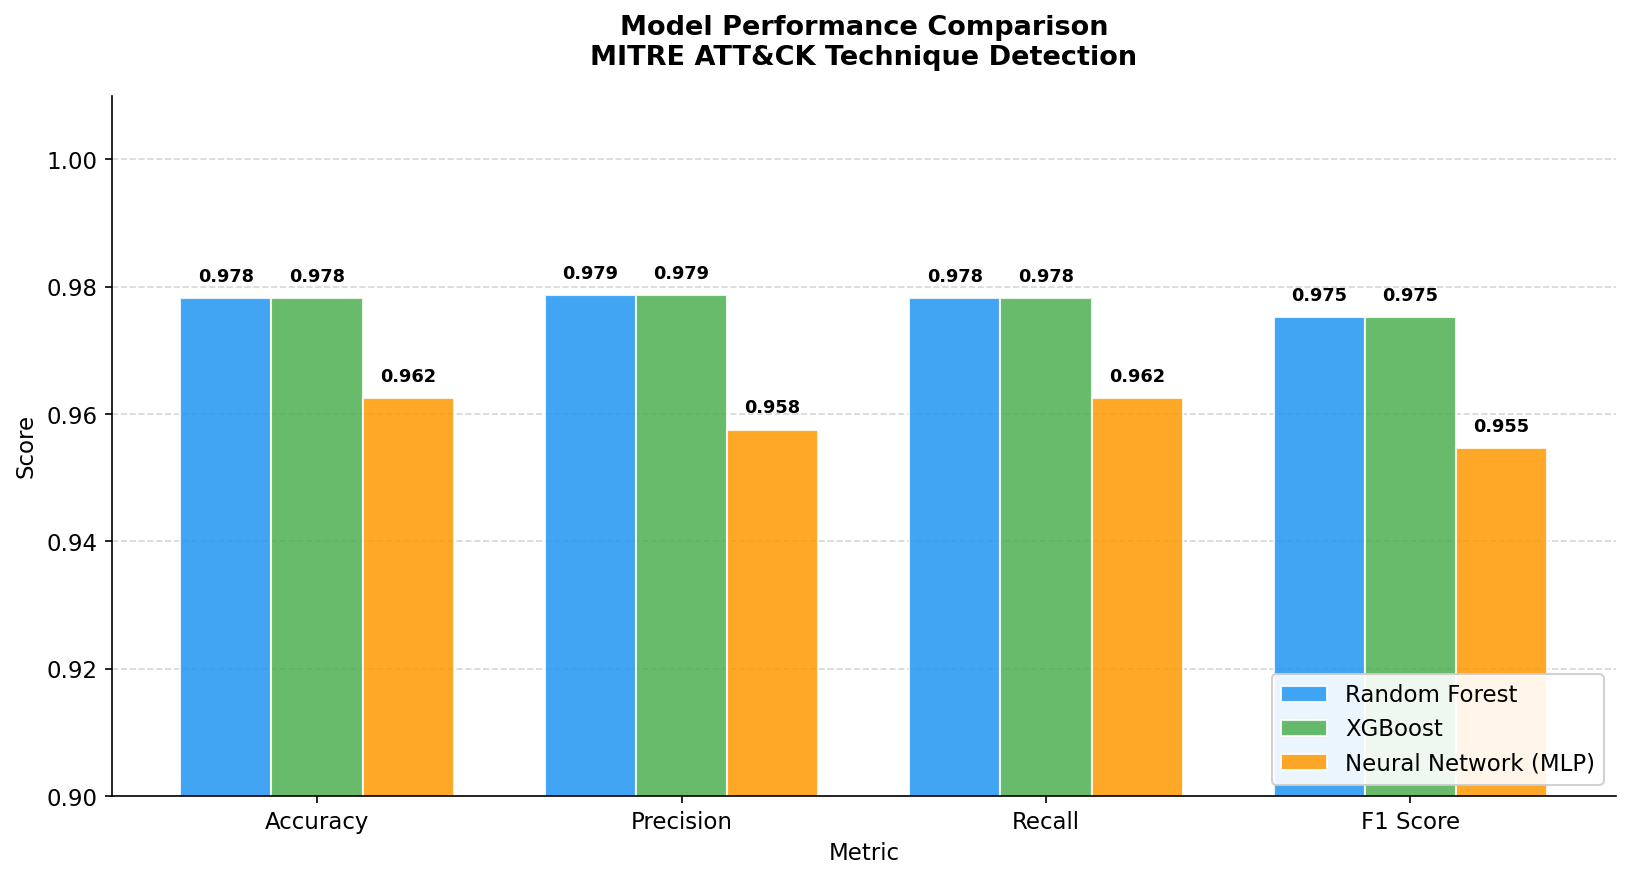

Saved: results/figures/01_model_comparison.png


In [10]:
# FIGURE 1: Model Comparison Bar Chart
print('Generating Figure 1: Model Comparison Bar Chart...')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
models  = results['Model'].tolist()
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(11, 6))

for i, (model, color) in enumerate(zip(models, colors)):
    values = [results.loc[results['Model'] == model, m].values[0] for m in metrics]
    bars = ax.bar(x + i * width, values, width, label=model, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison\nMITRE ATT&CK Technique Detection', fontweight='bold', pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0.90, 1.01)
ax.legend(loc='lower right', framealpha=0.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
sns.despine()

plt.tight_layout()
plt.savefig('../results/figures/01_model_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: results/figures/01_model_comparison.png')

Generating Figure 2: Confusion Matrices...


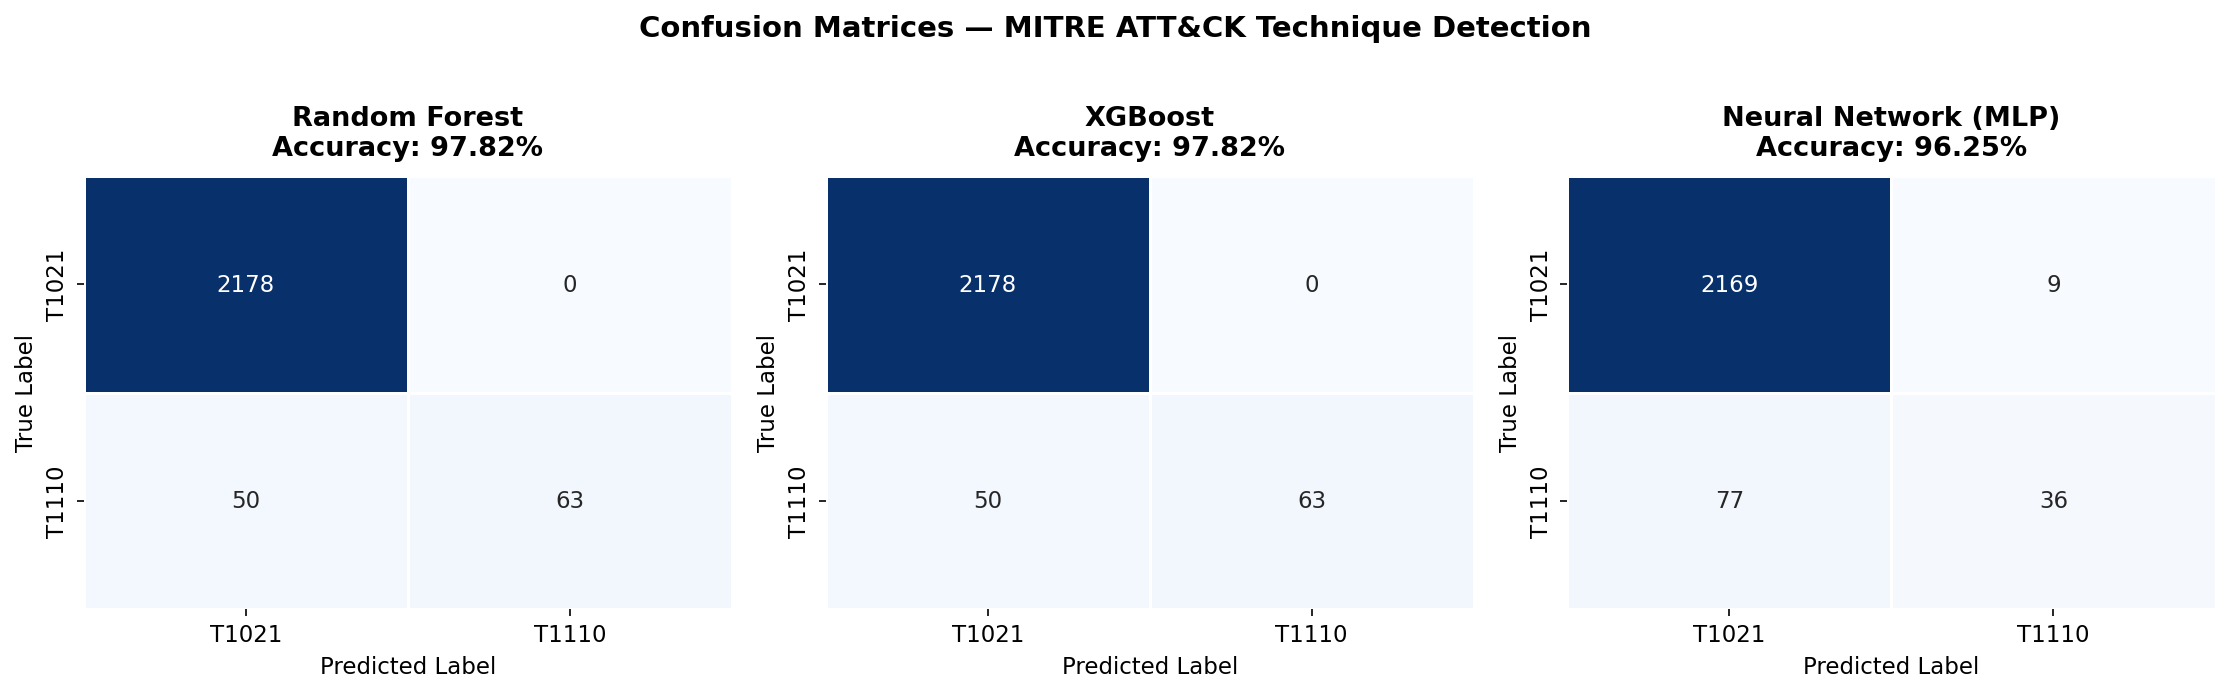

Saved: results/figures/02_confusion_matrices.png


In [11]:
# FIGURE 2: Confusion Matrices for all 3 models
print('Generating Figure 2: Confusion Matrices...')

pred_cols  = ['rf_pred', 'xgb_pred', 'mlp_pred']
model_names = ['Random Forest', 'XGBoost', 'Neural Network (MLP)']
y_true      = predictions['y_true']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Confusion Matrices — MITRE ATT&CK Technique Detection', 
             fontsize=14, fontweight='bold', y=1.02)

for ax, pred_col, model_name in zip(axes, pred_cols, model_names):
    cm  = confusion_matrix(y_true, predictions[pred_col], labels=actual_classes)
    acc = (cm.diagonal().sum() / cm.sum()) * 100
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=short_names, yticklabels=short_names,
                linewidths=0.5, linecolor='white', cbar=False)
    ax.set_title(f'{model_name}\nAccuracy: {acc:.2f}%', fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('../results/figures/02_confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Saved: results/figures/02_confusion_matrices.png')

Generating Figure 3: Feature Importance...


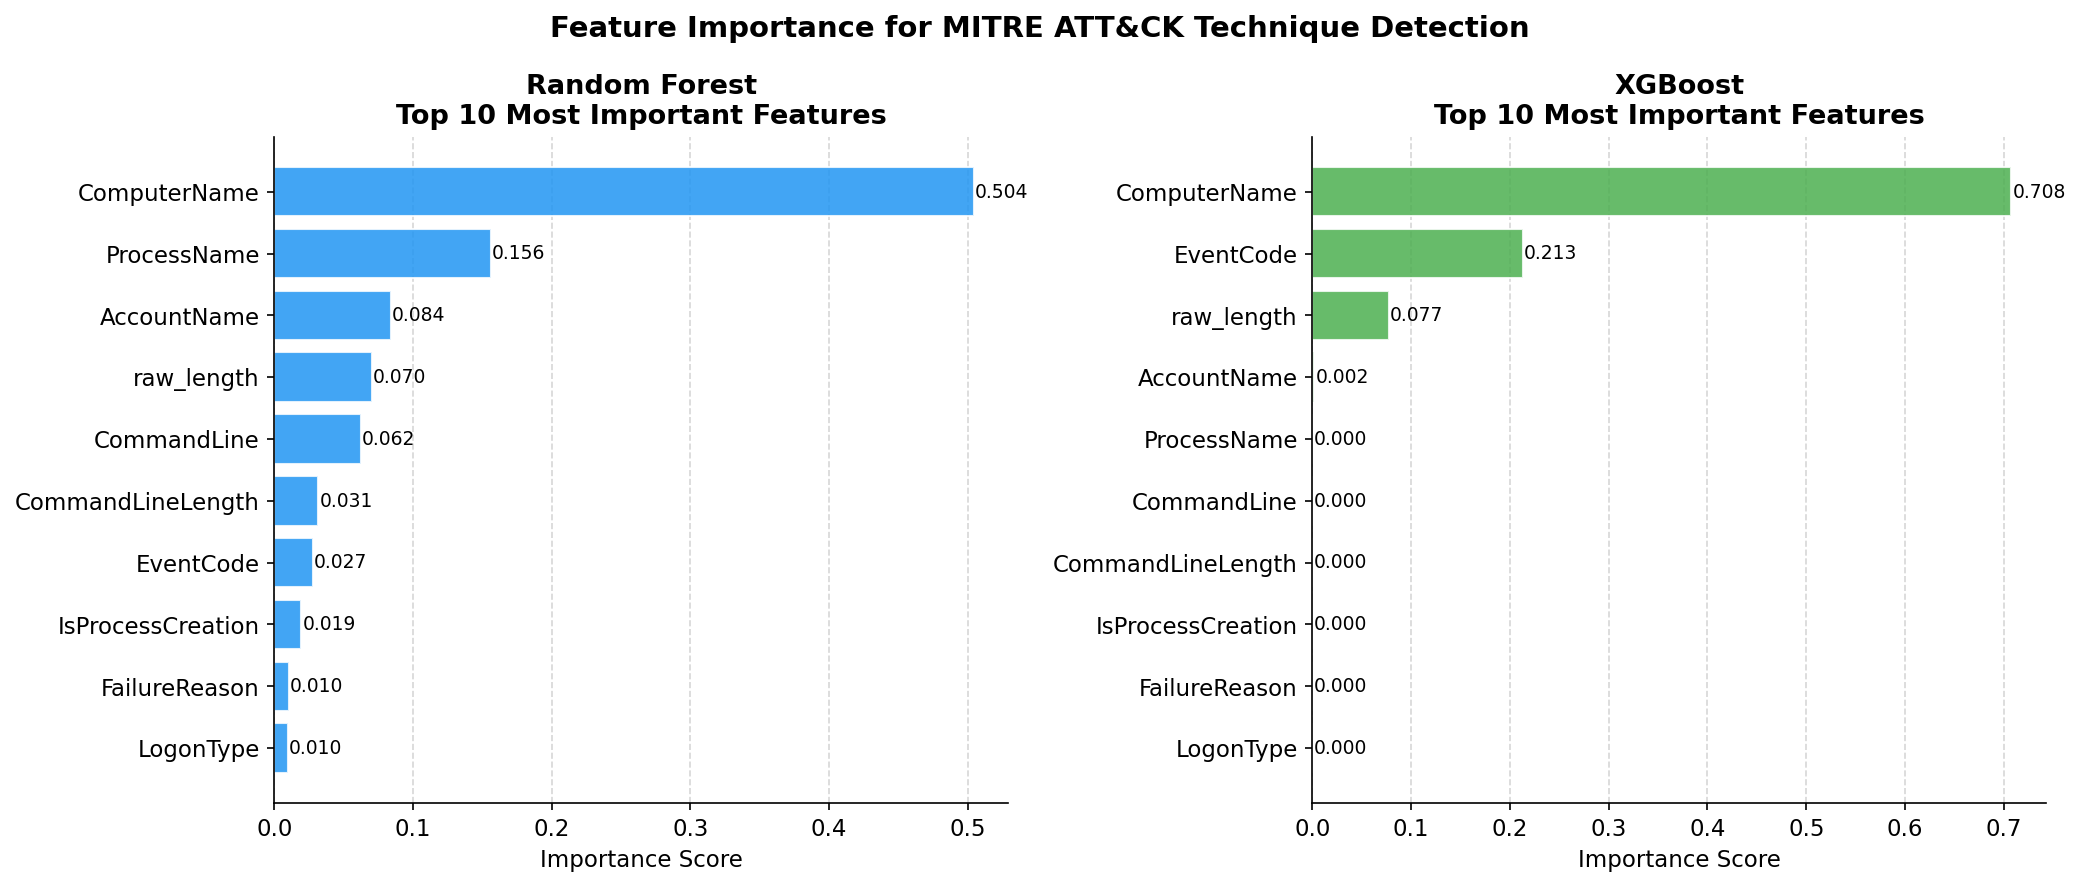

Saved: results/figures/03_feature_importance.png


In [12]:
# FIGURE 3: Feature Importance (Random Forest)
print('Generating Figure 3: Feature Importance...')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Importance for MITRE ATT&CK Technique Detection',
             fontsize=14, fontweight='bold')

for ax, col, model_name, color in zip(
    axes,
    ['importance_rf', 'importance_xgb'],
    ['Random Forest', 'XGBoost'],
    ['#2196F3', '#4CAF50']
):
    top10 = feat_imp.nlargest(10, col)
    bars  = ax.barh(top10['feature'], top10[col], color=color, alpha=0.85, edgecolor='white')
    ax.set_xlabel('Importance Score')
    ax.set_title(f'{model_name}\nTop 10 Most Important Features', fontweight='bold')
    ax.invert_yaxis()
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    for bar, val in zip(bars, top10[col]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('../results/figures/03_feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: results/figures/03_feature_importance.png')

Generating Figure 4: F1 Score Summary...


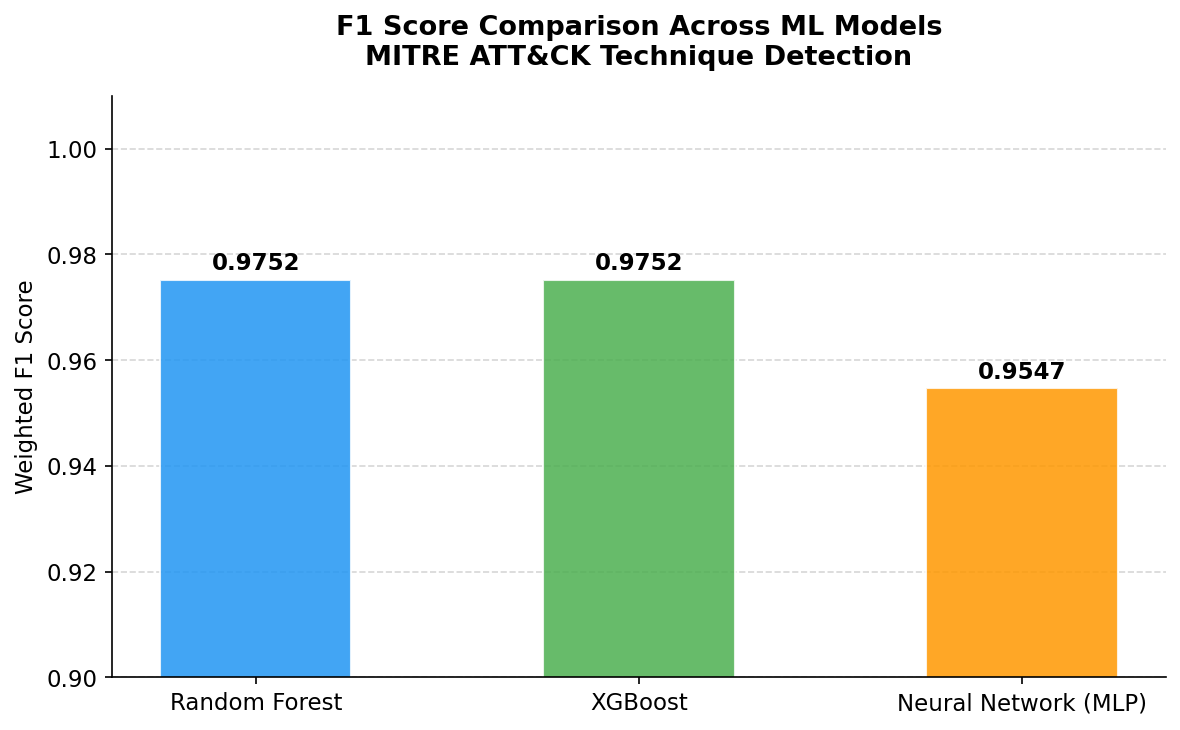

Saved: results/figures/04_f1_summary.png


In [13]:
# FIGURE 4: F1 Score Summary (clean single chart for thesis)
print('Generating Figure 4: F1 Score Summary...')

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800']
bars   = ax.bar(results['Model'], results['F1 Score'], color=colors, alpha=0.85,
                edgecolor='white', width=0.5)

for bar, val in zip(bars, results['F1 Score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Weighted F1 Score')
ax.set_title('F1 Score Comparison Across ML Models\nMITRE ATT&CK Technique Detection', 
             fontweight='bold', pad=15)
ax.set_ylim(0.90, 1.01)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
sns.despine()

plt.tight_layout()
plt.savefig('../results/figures/04_f1_summary.png', bbox_inches='tight')
plt.show()
print('Saved: results/figures/04_f1_summary.png')

In [14]:
# FINAL SUMMARY
print('=' * 50)
print('NOTEBOOK 04 COMPLETE ✅')
print('=' * 50)
print()
print('Thesis figures saved to results/figures/:')
print('  01_model_comparison.png  — bar chart (all metrics, all models)')
print('  02_confusion_matrices.png — heatmaps for all 3 models')
print('  03_feature_importance.png — top 10 features (RF + XGBoost)')
print('  04_f1_summary.png         — clean F1 comparison for thesis')
print()
print('FINAL MODEL RESULTS:')
print(results[['Model','Accuracy','F1 Score']].to_string(index=False))
print()
best_idx = results['F1 Score'].idxmax()
print(f'Best model: {results.loc[best_idx, "Model"]}')
print(f'Best F1:    {results.loc[best_idx, "F1 Score"]:.4f}')
print(f'Best Acc:   {results.loc[best_idx, "Accuracy"]:.4f} ({results.loc[best_idx, "Accuracy"]*100:.2f}%)')
print()

NOTEBOOK 04 COMPLETE ✅

Thesis figures saved to results/figures/:
  01_model_comparison.png  — bar chart (all metrics, all models)
  02_confusion_matrices.png — heatmaps for all 3 models
  03_feature_importance.png — top 10 features (RF + XGBoost)
  04_f1_summary.png         — clean F1 comparison for thesis

FINAL MODEL RESULTS:
               Model  Accuracy  F1 Score
       Random Forest  0.978175  0.975199
             XGBoost  0.978175  0.975199
Neural Network (MLP)  0.962462  0.954672

Best model: Random Forest
Best F1:    0.9752
Best Acc:   0.9782 (97.82%)

